In [1]:
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

In [2]:
#Load Preprocessed Data
X_train = np.load("../data/processed/X_train.npy")
y_train = np.load("../data/processed/y_train.npy")
X_test  = np.load("../data/processed/X_test.npy")
y_test  = np.load("../data/processed/y_test.npy")

X_train.shape, y_train.shape


((1159, 60, 5), (1159,))

In [5]:
#Build LSTM Model

model = Sequential()

model.add(LSTM(64, return_sequences=True, input_shape=(X_train.shape[1], X_train.shape[2])))
model.add(Dropout(0.2))

model.add(LSTM(64))
model.add(Dropout(0.2))

model.add(Dense(1))

model.compile(
    optimizer="adam",
    loss="mean_squared_error"
)

model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_4 (LSTM)                   │ (None, 60, 64)         │        17,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 60, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_5 (LSTM)                   │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 51,009 (199.25 KB)

 Trainable params: 51,009 (199.25 KB)

 Non-trainable params: 0 (0.00 B)

In [6]:
#Train the Model
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

history = model.fit(
    X_train,
    y_train,
    validation_split=0.1,
    epochs=50,
    batch_size=32,
    callbacks=[early_stop]
)



Epoch 1/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 4s 46ms/step - loss: 0.0115 - val_loss: 0.0036
Epoch 2/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - loss: 0.0021 - val_loss: 5.7317e-04
Epoch 3/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - loss: 0.0019 - val_loss: 9.9132e-04
Epoch 4/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - loss: 0.0017 - val_loss: 9.0807e-04
Epoch 5/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - loss: 0.0018 - val_loss: 9.9321e-04
Epoch 6/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step - loss: 0.0017 - val_loss: 5.7306e-04
Epoch 7/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - loss: 0.0016 - val_loss: 6.9779e-04
Epoch 8/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 40ms/step - loss: 0.0015 - val_loss: 7.8175e-04
Epoch 9/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - loss: 0.0015 - val_loss: 4.9227e-04
Epoch 10/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - loss: 0.0013 - val_loss: 5.7542e-04
Epoch 11/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - loss: 0.0013 - val_loss: 5.7667e-04
Epoch 12/50
33/33 ━━━━━

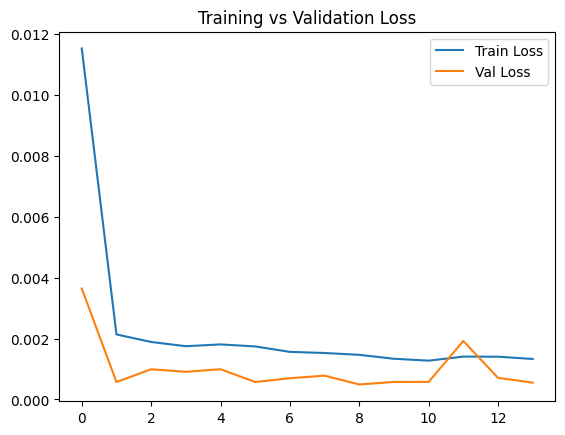

In [7]:
#Plot Training Loss

plt.figure()
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Val Loss")
plt.legend()
plt.title("Training vs Validation Loss")
plt.show()


In [8]:
#make prediction 
y_pred = model.predict(X_test)


10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 40ms/step


In [9]:
from sklearn.preprocessing import MinMaxScaler
#Inverse Scaling

In [10]:
scaler = MinMaxScaler()
scaler.fit(np.concatenate((y_train.reshape(-1,1), y_test.reshape(-1,1))))

y_test_inv = scaler.inverse_transform(y_test.reshape(-1, 1))
y_pred_inv = scaler.inverse_transform(y_pred)

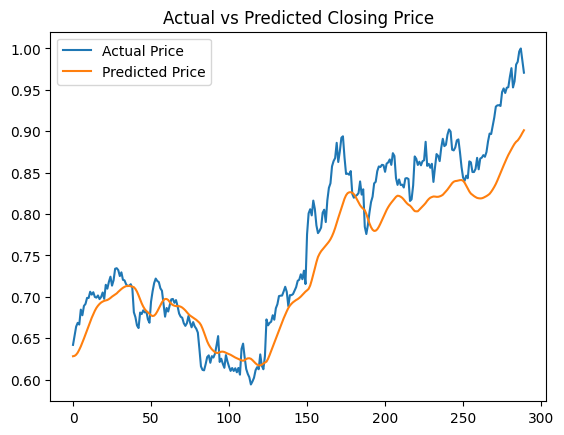

In [11]:
plt.figure()
plt.plot(y_test_inv, label="Actual Price")
plt.plot(y_pred_inv, label="Predicted Price")
plt.legend()
plt.title("Actual vs Predicted Closing Price")
plt.show()

In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

#Evaluate the model

In [13]:
rmse = np.sqrt(mean_squared_error(y_test_inv, y_pred_inv))
mae = mean_absolute_error(y_test_inv, y_pred_inv)

rmse, mae

(np.float64(0.04323551387641754), 0.03441347411713931)

In [15]:
#save the model 
model.save("../models_saved/lstm/lstm_price_model.h5")
